In [17]:
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from operators import productN
import numpy as np
#from helps_and_enhancers import *
import matplotlib.pyplot as plt
from ANFIS import ANFIS
import time
import copy
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

<H1>Przygotowanie zbioru danych: XOR<H1>

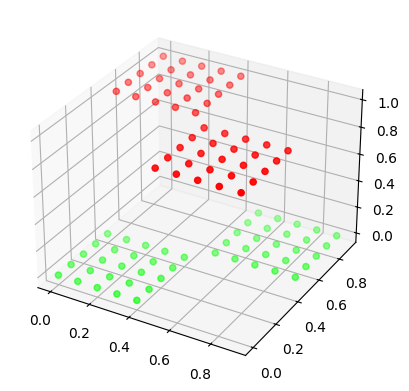

In [18]:
x = np.arange(0, 1, 0.1)
x,y = np.meshgrid(x, x)

dataX = x.flatten()
dataY = y.flatten()
dataXY1 = np.column_stack((dataX,dataY,np.ones(len(dataX))))
dataXY = np.column_stack((dataX,dataY))

data_labels = np.logical_xor(dataX >= 0.5, dataY >= 0.5) 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

rgb = [[1,0,0] if cc else [0,1,0] for cc in data_labels]

ax.scatter(dataX, dataY, data_labels, c=rgb)

plt.show()

<H1>Utworzenie funkcji przynależności</H1>

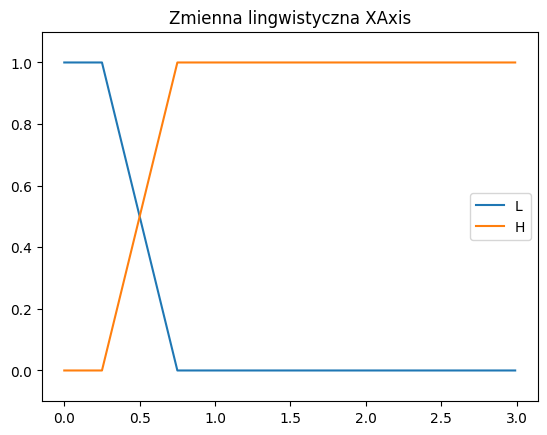

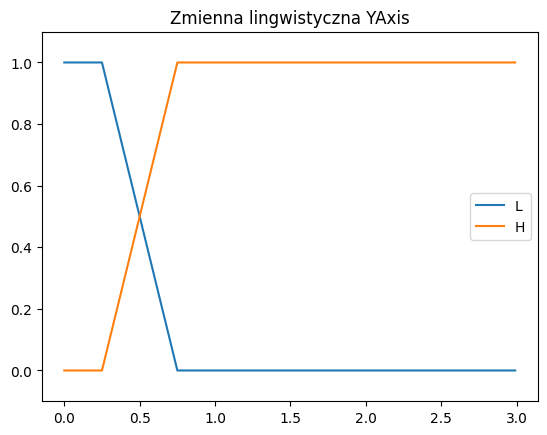

In [19]:
varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "XAxis", ["L","H"]) # low, high
varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "YAxis", ["L","H"])

#mf1 = [[-0.5, 0.25, 0.25, 0.25], [0.5, 0.25, 0.1, 0.1]]
#varX = FuzzyInputVariable_List_Trapezoids(mf1, "XAxis", ["L","H"])
#varY = FuzzyInputVariable_List_Trapezoids(mf1, "YAxis", ["L","H"])

#Wyświetlanie funkcji przynależnosci
plt.figure()
varX.show()
plt.legend()

plt.figure()
varY.show()
plt.legend()

plt.show()

<H1>Inicjalizacja systemu ANFIS</H1>

Parametry początkowe:
Przesłanki:  [[0.5, 0.5], [0.5, 0.5]] 
Konkluzje:  [[0.61494518 0.65637422 0.5608613 ]
 [0.22284452 0.27159322 0.71433372]
 [0.27499891 0.43899755 0.8988858 ]
 [0.01080394 0.0195084  0.22817259]]


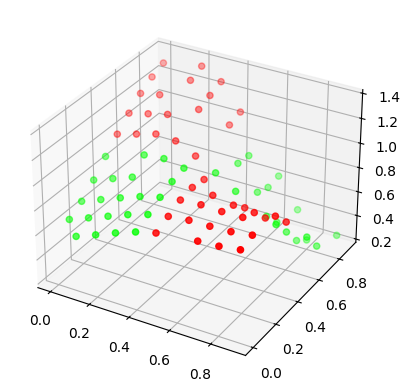

In [20]:
X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

fis = ANFIS([varX, varY], X_train.T, y_train)

print("Parametry początkowe:\nPrzesłanki: ",fis.premises, "\nKonkluzje: ", fis.tsk)

fis.show_results()

<H1>Uczenie systemu ANFIS</H1>

Optymalizacja zakończona!
z blędem:   5.4373950096774136e-06
Liczba ew:  33428
Liczba it:  50
TIME elapsed:  4.406902074813843


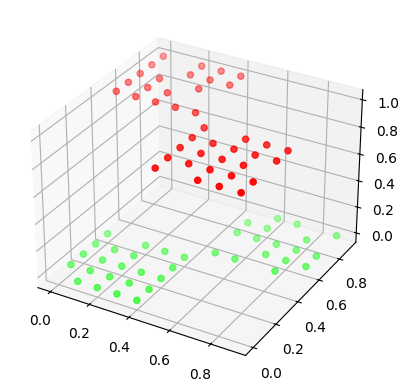

In [21]:
start = time.time()
fis.train(True, True, False, True, n_iter=50)
end = time.time()
print("TIME elapsed: ", end - start)   
fis.training_data = X_train.T
fis.expected_labels = y_train
fis.show_results()

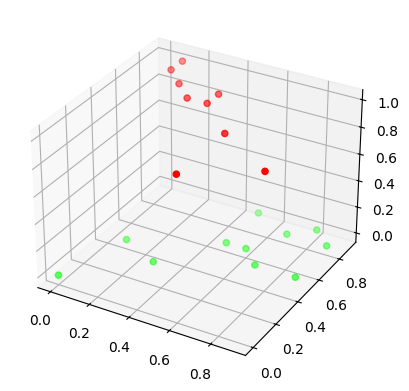

[[11  0]
 [ 0  9]]


In [22]:
fis.training_data = X_test.T
fis.expected_labels = y_test
fis.show_results()

y_pred = fis.anfis_estimate_labels(fis.premises,fis.op,fis.tsk)
y_pred = list(map(round,y_pred.flatten()))
print(confusion_matrix(y_test, y_pred))

<H1>Sprawdzanie parametrów jakich nauczył się system</H1>

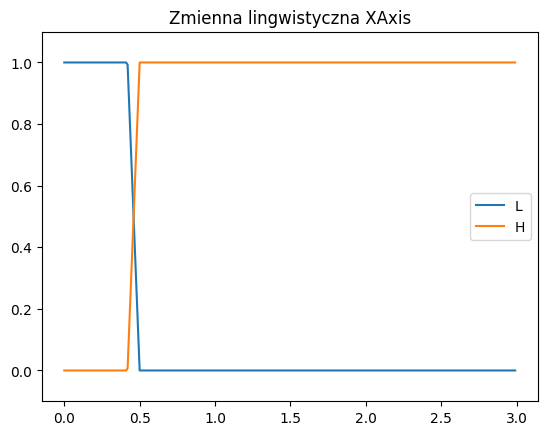

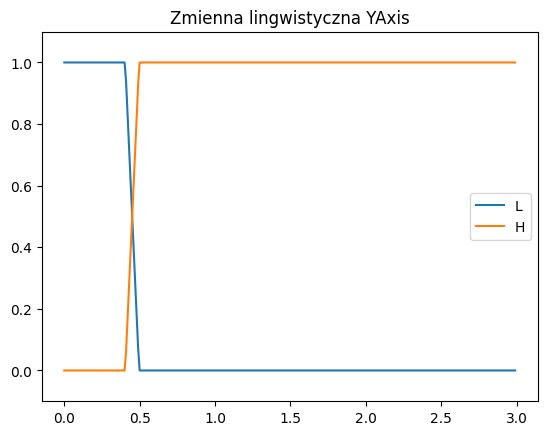

In [23]:
#Wyświetlanie funkcji przynależnosci
plt.figure()
varX.show()
plt.legend()

plt.figure()
varY.show()
plt.legend()

plt.show()

In [24]:
print("Parametry końcowe:\nPrzesłanki: ", repr(fis.premises), "\nKonkluzje: ", repr(fis.tsk))

Parametry końcowe:
Przesłanki:  array([[0.4595345 , 0.08018286],
       [0.45035555, 0.09241088]]) 
Konkluzje:  array([[6.00540394e-14, 5.99308665e-14, 2.85971201e-13],
       [8.55525957e-07, 3.31447610e-07, 9.99999176e-01],
       [6.52280681e-07, 1.93594787e-07, 9.99999753e-01],
       [1.56862565e-13, 1.56145096e-13, 2.25943223e-13]])


#### Zapisanie nauczonych parametrów do zmiennych

In [25]:
learned_premises = fis.premises.copy()
learned_tsk = fis.tsk.copy()

<H1>Sprawdzanie wpływu parametrów na wyniki systemu</H1>

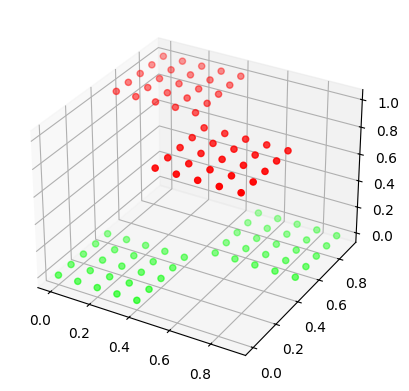

In [26]:
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

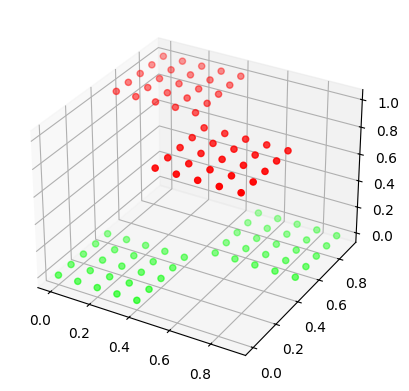

In [27]:
fis.premises = learned_premises
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

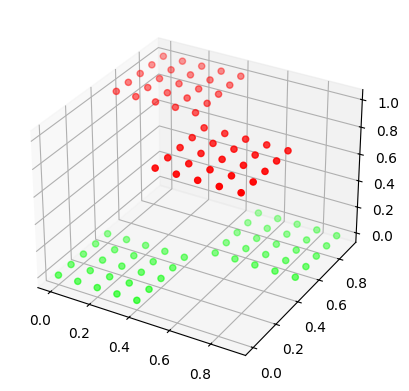

In [28]:
fis.tsk = learned_tsk
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

<H1>Zadanie</H1>

Naucz system ANFIS tabliczki mnożenia. Zacznij od rozmiaru 2x2 i zwiększaj w obu kierunkach z krokiem 1 (kolejno 2x2, 3x3, 4x4, 5x5). Mierz czas jaki jest potrzebny na nauczenie systemu w zależności od wymiarów tabliczki. Zrób wykres wymiaru tabliczki od czasu uczenia i wyślij wraz ze swoim komentarzem na maila iperenc@kis.p.lodz.pl. Nie musisz dojść do rozmiaru 10x10, wystarczy 5x5, ważne żeby było widać jaka jest zależność.

Uczenie tabliczki mnożenia 2x2
Optymalizacja zakończona!
z blędem:   0.00022365715233640948
Liczba ew:  41365
Liczba it:  50
Uczenie tabliczki mnożenia 3x3
Optymalizacja zakończona!
z blędem:   0.00022365715233640948
Liczba ew:  41365
Liczba it:  50
Uczenie tabliczki mnożenia 3x3
Optymalizacja zakończona!
z blędem:   0.00019510639671471708
Liczba ew:  48672
Liczba it:  50
Uczenie tabliczki mnożenia 4x4
Optymalizacja zakończona!
z blędem:   0.00019510639671471708
Liczba ew:  48672
Liczba it:  50
Uczenie tabliczki mnożenia 4x4
Optymalizacja zakończona!
z blędem:   0.0015120283677083624
Liczba ew:  53797
Liczba it:  50
Uczenie tabliczki mnożenia 5x5
Optymalizacja zakończona!
z blędem:   0.0015120283677083624
Liczba ew:  53797
Liczba it:  50
Uczenie tabliczki mnożenia 5x5
Optymalizacja zakończona!
z blędem:   278.75073734494833
Liczba ew:  55295
Liczba it:  50
Optymalizacja zakończona!
z blędem:   278.75073734494833
Liczba ew:  55295
Liczba it:  50


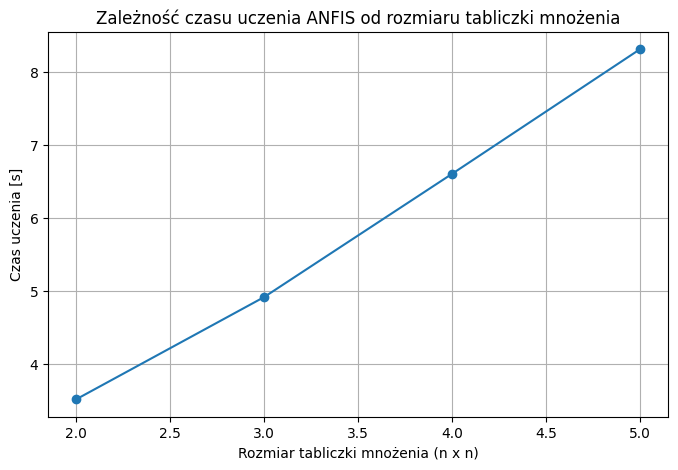

In [38]:
training_times = []
table_sizes = range(2, 6)

for size in table_sizes:
    print(f"Uczenie tabliczki mnożenia {size}x{size}")

    # Przygotowanie danych dla tabliczki mnożenia size x size
    x_vals = np.linspace(1, size, size*10)
    y_vals = np.linspace(1, size, size*10)
    xx, yy = np.meshgrid(x_vals, y_vals)
    dataXY_mul = np.column_stack((xx.flatten(), yy.flatten()))
    labels_mul = (xx * yy).flatten()

    # Tworzenie funkcji przynależności
    varX_mul = FuzzyInputVariable_2Trapezoids((size-1)/2, (size-1)/2, "X", ["L", "H"])
    varY_mul = FuzzyInputVariable_2Trapezoids((size-1)/2, (size-1)/2, "Y", ["L", "H"])

    # Podział na zbiór treningowy i testowy
    X_train_mul, X_test_mul, y_train_mul, y_test_mul = train_test_split(dataXY_mul, labels_mul, test_size=0.2, random_state=25)

    # Inicjalizacja i uczenie ANFIS
    fis_mul = ANFIS([varX_mul, varY_mul], X_train_mul.T, y_train_mul)
    start_mul = time.time()
    fis_mul.train(True, True, False, True, n_iter=50)
    end_mul = time.time()
    training_times.append(end_mul - start_mul)

# Wykres zależności wymiaru tabliczki od czasu uczenia
plt.figure(figsize=(8, 5))
plt.plot(list(table_sizes), training_times, marker='o')
plt.xlabel('Rozmiar tabliczki mnożenia (n x n)')
plt.ylabel('Czas uczenia [s]')
plt.title('Zależność czasu uczenia ANFIS od rozmiaru tabliczki mnożenia')
plt.grid(True)
plt.show()